# Model Training — Fake News Classifier
**Prepared by: Md. Roton Ahmed**

## 1. Load and Preprocess

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import joblib
import warnings
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [16]:
df = pd.read_csv('../data/fake_and_real_news.csv')
df = df.drop_duplicates().dropna()
print('Dataset shape:', df.shape)
print('Label distribution:')
print(df['label'].value_counts())

Dataset shape: (9865, 2)
Label distribution:
label
Fake    5000
Real    4865
Name: count, dtype: int64


### Text Preprocessing

In [17]:
STOP_WORDS = set(stopwords.words('english'))

def preprocess_text(text):
    """Lowercase → remove punctuation → remove stopwords."""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

# Apply preprocessing
print('Preprocessing text...')
df['clean_text'] = df['Text'].apply(preprocess_text)
print('Preprocessing done!')
print('\nExample (original):', df['Text'].iloc[0][:80], '...')
print('Example (clean):   ', df['clean_text'].iloc[0][:80], '...')

Preprocessing text...
Preprocessing done!

Example (original):  Top Trump Surrogate BRUTALLY Stabs Him In The Back: ‘He’s Pathetic’ (VIDEO) It  ...
Example (clean):    top trump surrogate brutally stabs back ‘he’s pathetic’ video looking though rep ...


## 2. Train/Test Split

In [18]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')
print(f'\nTrain label distribution:\n{y_train.value_counts()}')
print(f'\nTest label distribution:\n{y_test.value_counts()}')

Training samples : 7892
Testing samples  : 1973

Train label distribution:
label
Fake    4000
Real    3892
Name: count, dtype: int64

Test label distribution:
label
Fake    1000
Real     973
Name: count, dtype: int64


## 3. Train Multiple Models

In [19]:
# Define pipelines: TF-IDF + Classifier
pipelines = {
    'Multinomial Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
        ('clf',   MultinomialNB())
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
        ('clf',   LogisticRegression(max_iter=1000, random_state=42, C=1.0))
    ])
}

results = {}
trained_pipelines = {}

for name, pipeline in pipelines.items():
    print(f'Training {name}...')
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='Fake')
    rec  = recall_score(y_test, y_pred, pos_label='Fake')
    f1   = f1_score(y_test, y_pred, pos_label='Fake')

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    trained_pipelines[name] = (pipeline, y_pred)

    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1-Score : {f1:.4f}\n')

print('Training complete!')

Training Multinomial Naive Bayes...
  Accuracy : 0.9812
  F1-Score : 0.9815

Training Logistic Regression...
  Accuracy : 0.9939
  F1-Score : 0.9940

Training complete!


## 4. Confusion Matrices

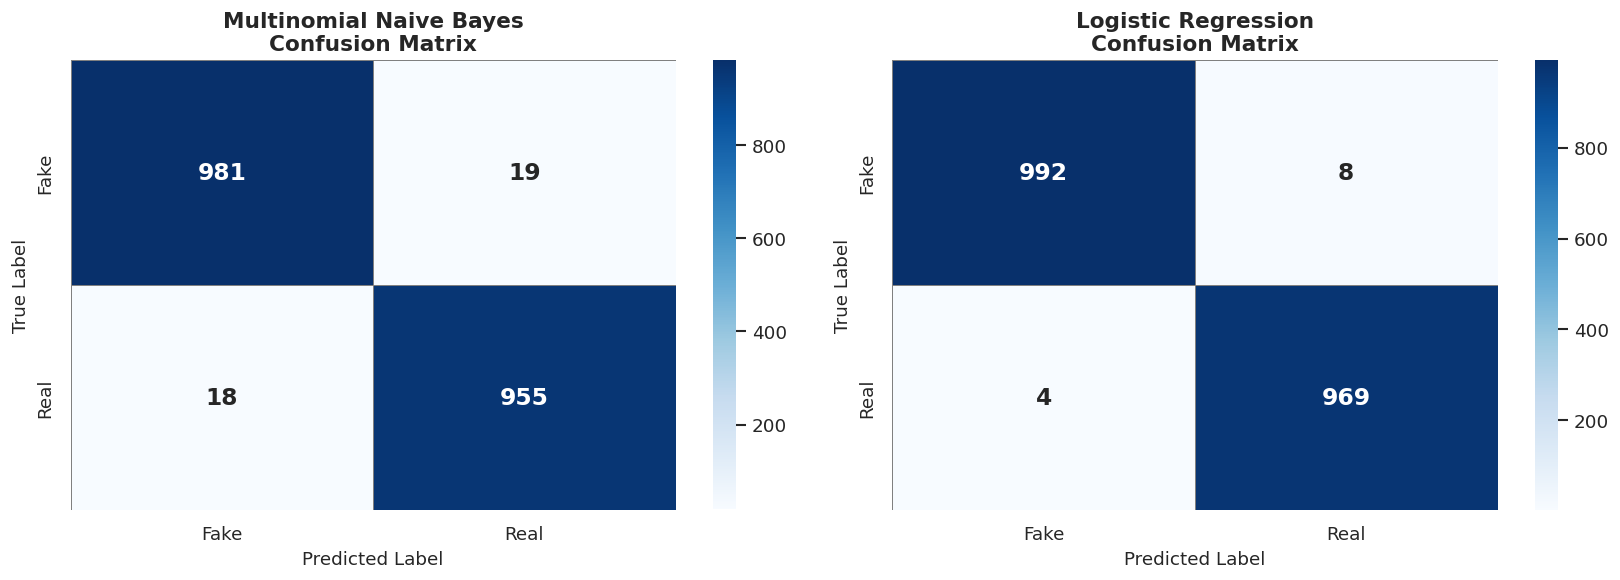

Confusion matrices saved.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Fake', 'Real']

for ax, (name, (pipeline, y_pred)) in zip(axes, trained_pipelines.items()):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        ax=ax, linewidths=0.5, linecolor='gray',
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('../screenshots/confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Confusion matrices saved.')

## 5. Model Comparison & Best Model Selection

In [21]:
results_df = pd.DataFrame(results).T.round(4)
print('='*65)
print('         MODEL COMPARISON TABLE')
print('='*65)
print(results_df.to_string())
print('='*65)

         MODEL COMPARISON TABLE
                         Accuracy  Precision  Recall  F1-Score
Multinomial Naive Bayes    0.9812      0.982   0.981    0.9815
Logistic Regression        0.9939      0.996   0.992    0.9940


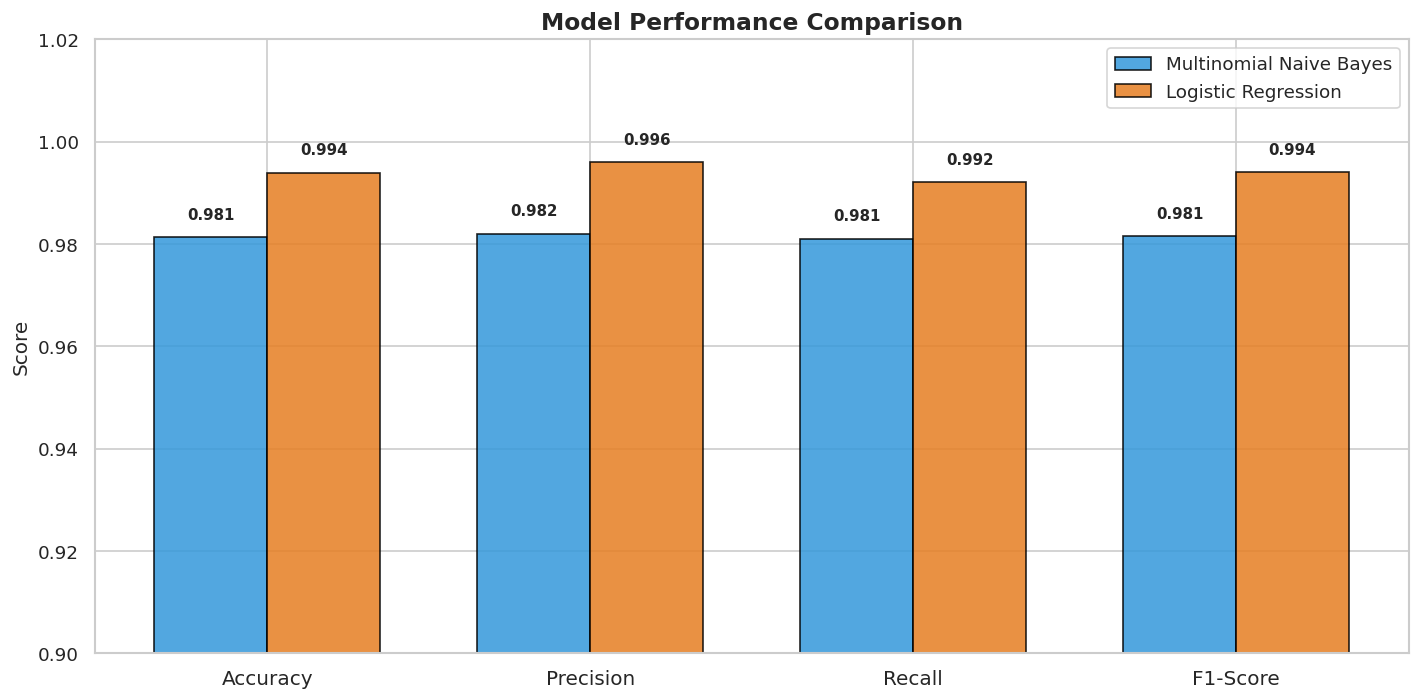

In [22]:
# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#3498db', '#e67e22']

for i, (name, color) in enumerate(zip(results.keys(), colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name, color=color, alpha=0.85, edgecolor='black')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width/2)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0.9, 1.02)

plt.tight_layout()
plt.savefig('../screenshots/model_comparison.png', bbox_inches='tight')
plt.show()

In [23]:
# Select best model by F1-Score
best_model_name = results_df['F1-Score'].idxmax()
best_pipeline   = trained_pipelines[best_model_name][0]

print(f'\nBest Model: {best_model_name}')
print(f"   Accuracy : {results[best_model_name]['Accuracy']:.4f}")
print(f"   F1-Score : {results[best_model_name]['F1-Score']:.4f}")
print('\nFull classification report:')
print(classification_report(y_test, trained_pipelines[best_model_name][1]))


Best Model: Logistic Regression
   Accuracy : 0.9939
   F1-Score : 0.9940

Full classification report:
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      1000
        Real       0.99      1.00      0.99       973

    accuracy                           0.99      1973
   macro avg       0.99      0.99      0.99      1973
weighted avg       0.99      0.99      0.99      1973



## 6. Save Best Pipeline

In [24]:
import os
os.makedirs('../models', exist_ok=True)

# Save both the pipeline and preprocessing function
model_data = {
    'pipeline': best_pipeline,
    'model_name': best_model_name,
    'metrics': results[best_model_name]
}

joblib.dump(model_data, '../models/best_model.pkl')
print('Pipeline saved to ../models/best_model.pkl')

# Quick sanity check
loaded = joblib.load('../models/best_model.pkl')
sample_pred = loaded['pipeline'].predict(['Trump won the election fraud hoax rigged'])
print(f'\nSanity check prediction: {sample_pred[0]}')
print('Model loads and predicts correctly.')

Pipeline saved to ../models/best_model.pkl

Sanity check prediction: Fake
Model loads and predicts correctly.
